# Credit Card Fraud Detection in Azure ML Studio

Emilie McGregor -  https://github.com/emsbc/azureml-example/blob/main/jupyter/anomaly_detection_creditcard.ipynb

## Bottom Line Up Front

This notebook scans a portfolio of ~285,000 credit card transactions, flags the ones most likely to be fraud, and then walks you through what the results mean for the business — including what it costs when the model is wrong.

The model uses an **Isolation Forest** algorithm. It doesn't learn what fraud looks like — it learns what *normal* looks like and flags everything that doesn't fit. Think of it as a security camera that memorizes the usual foot traffic pattern and alerts you when someone walks in the wrong direction.

**What you get at the end:**
- A count of flagged transactions and how that compares to the known fraud rate.
- Charts showing the dollar profile of flagged transactions and which behavioral signals drove each flag — so a risk analyst can challenge or confirm any individual case.
- A **cost-benefit analysis** that puts dollar estimates on both types of errors: false alarms vs. missed fraud. The numbers make it clear which direction to tune.
- A **deployment roadmap** from this proof of concept to a production real-time scoring system, with specific improvement recommendations.
- A **risk assessment** covering six identified risks — from model drift to regulatory exposure — each with a concrete mitigation strategy.
- A **stakeholder communication plan** tailored to five audiences, so your board, your fraud team, your compliance group, and your customers all hear the right message in the right language.

**The honest caveat:** At current settings, the model catches roughly 28% of real fraud cases. That's not a bug — it's a tuning decision, and the cost-benefit analysis at the bottom explains exactly why we recommend adjusting it. A more aggressive setting catches more fraud but generates more false alarms. That tradeoff is yours to make — but the data in this notebook gives you what you need to make it with confidence.


---

## Setup Requirements

Before running this notebook:

1. You'll need an Azure account with a [Subscription](https://techcommunity.microsoft.com/discussions/azure/understanding-azure-account-subscription-and-directory-/34800) and a [Workspace](https://learn.microsoft.com/en-us/azure/machine-learning/concept-workspace?view=azureml-api-2) already created.
2. The [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) dataset from Kaggle must be uploaded to `Assets -> Data` in your Azure account under the name `creditcard_fraud`.

This notebook runs in either the **Azure AI Machine Learning Studio** (recommended) or locally with Python 3.9 — see the course [GitHub repository](https://github.com/FullStackWithLawrence/azureml-example) for the virtual environment setup.

---
## How the Whole Thing Works — End to End

Here's the complete pipeline from raw data to actionable fraud flags. Each box is a step; the arrows show what feeds into what.

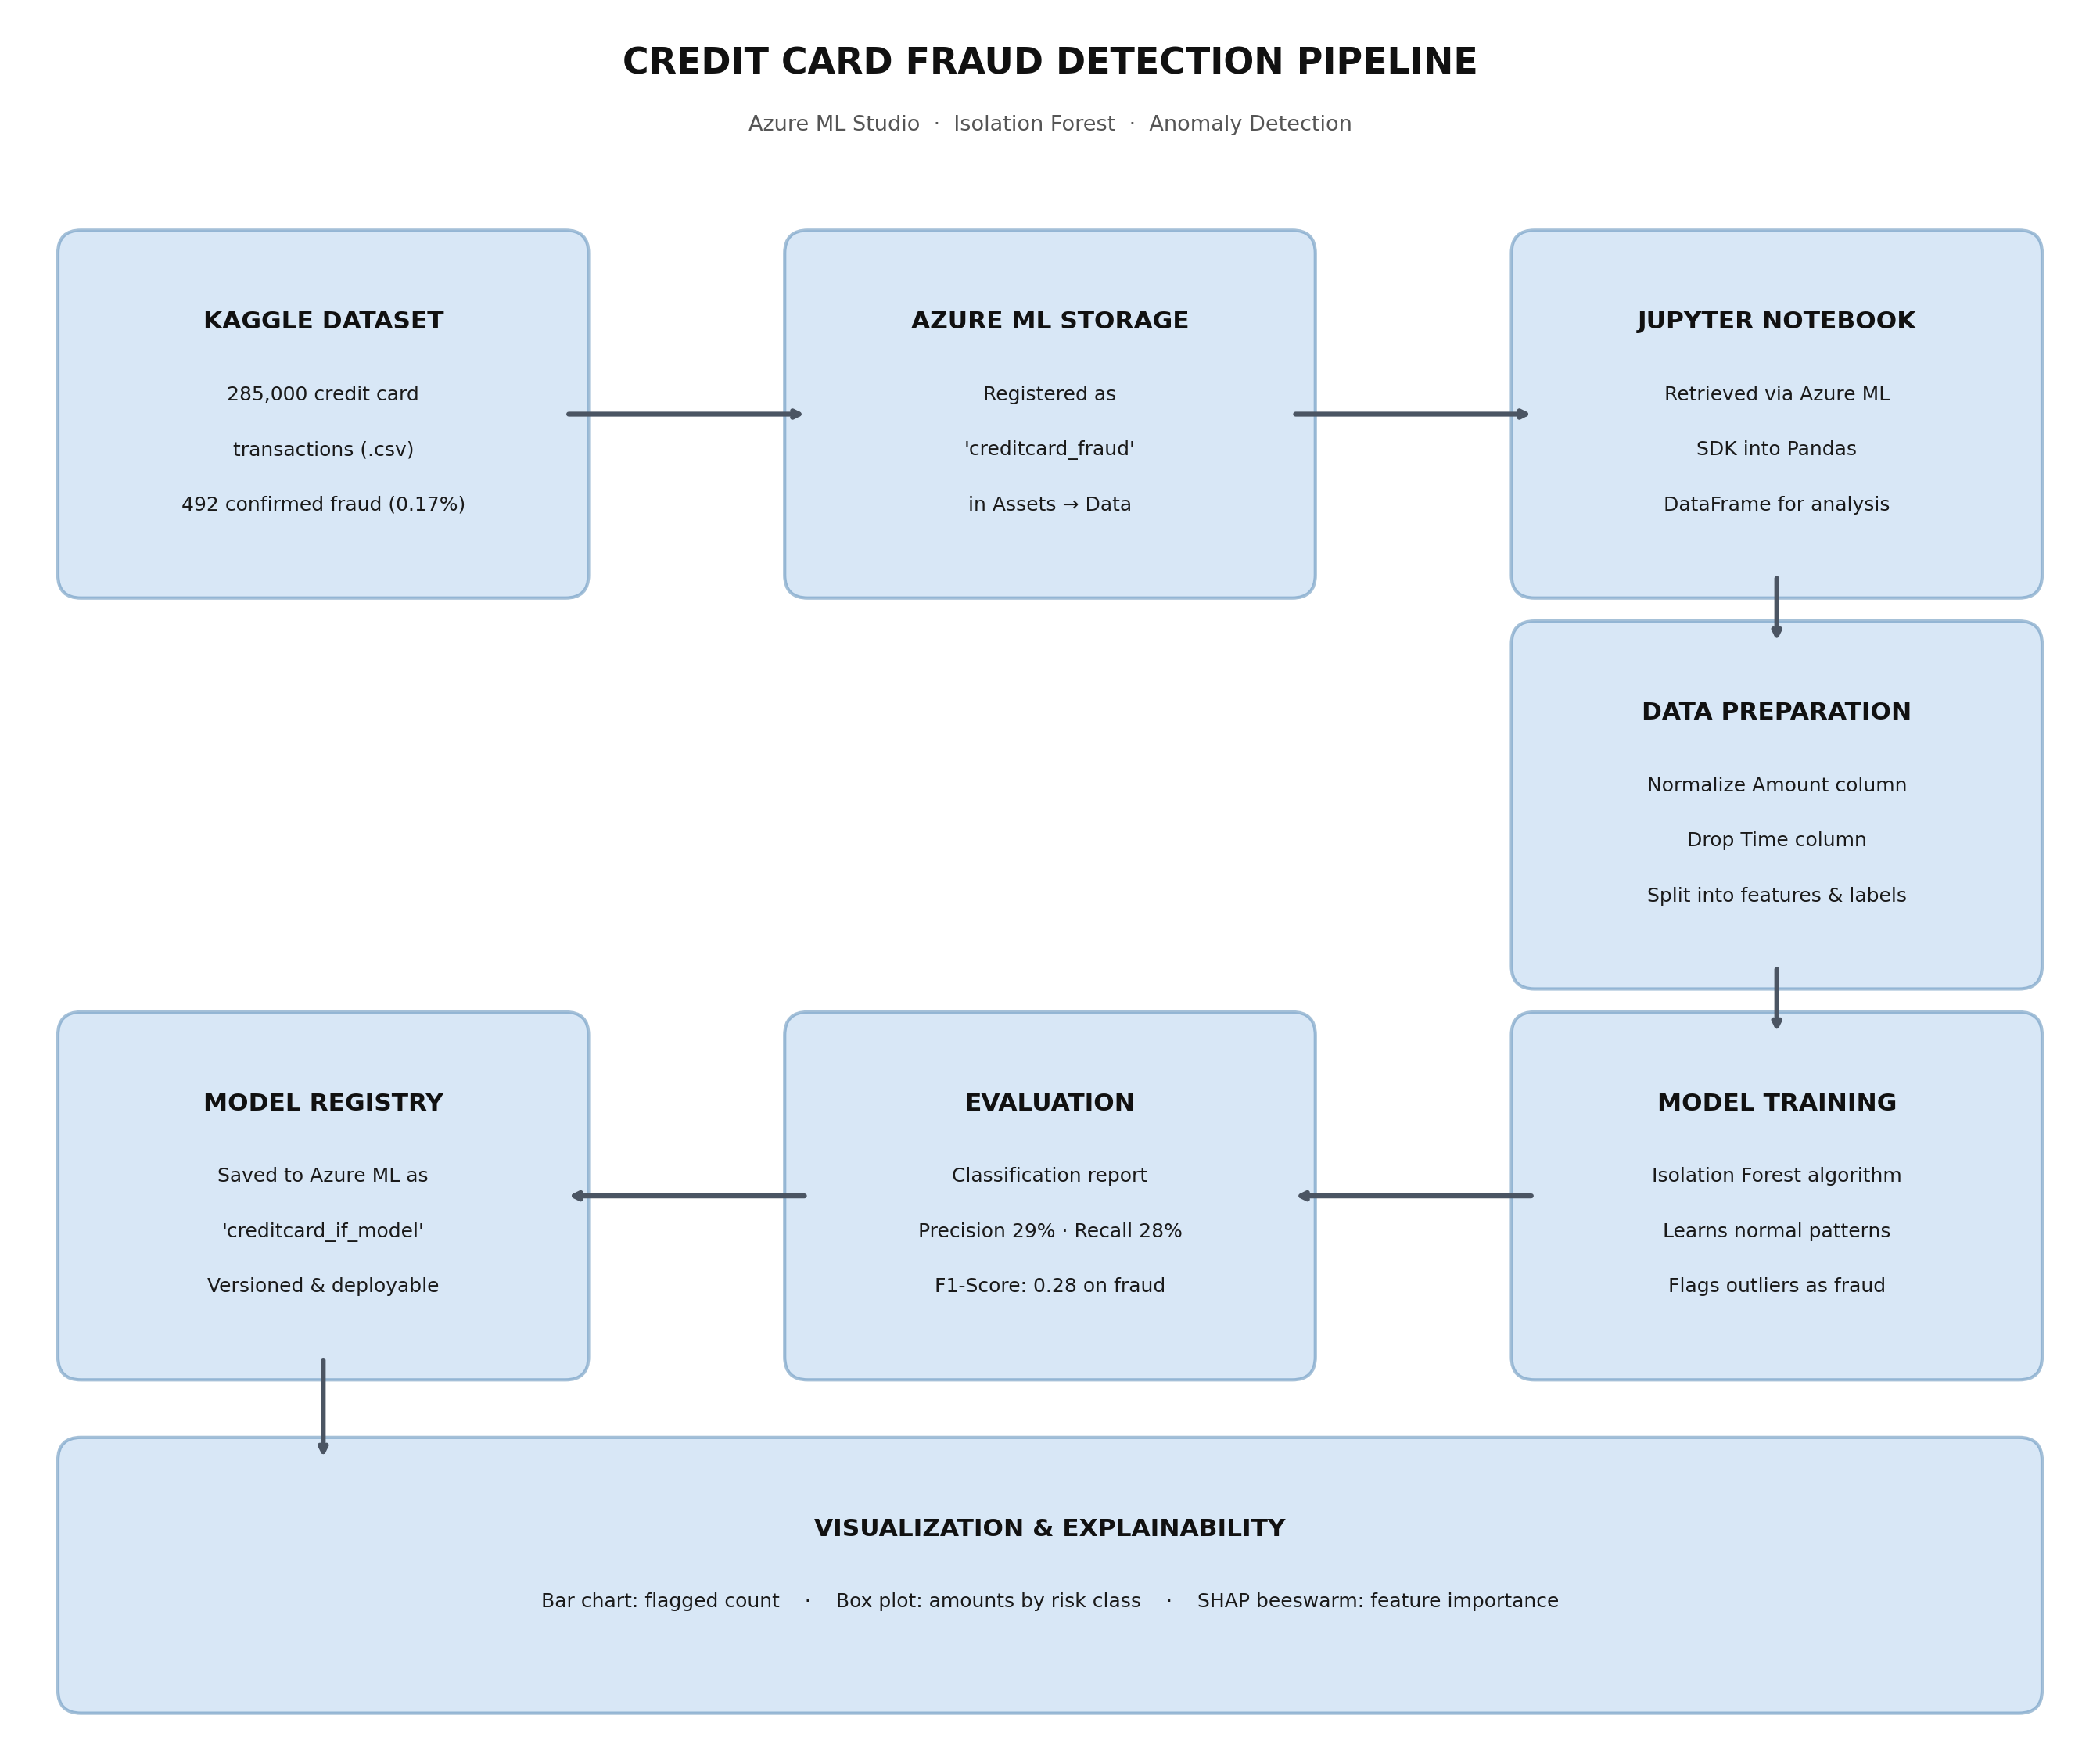

**In plain language:** we take a big pile of transaction records, store them securely in Azure, clean them up so the math works properly, run a model that separates the normal from the unusual, measure how well it did, save it for reuse, and then generate charts so your team can see exactly what the model flagged and why.

## Azure ML Components Used in This Pipeline

The table below maps every Azure Machine Learning component used in this notebook to what it actually does for you. If you hear your data science team mention any of these, this is what they mean.

| Azure ML Component | Role in This Process |
|---|---|
| **Azure Subscription** | The billing container — this is the account-level agreement that authorizes your organization to use Azure services and tracks costs. |
| **Azure ML Workspace** | The central hub where all ML assets live — datasets, notebooks, models, and compute resources. Think of it as the project folder that keeps everything organized and access-controlled. |
| **Assets → Data** (Registered Dataset) | The Kaggle credit card fraud dataset is uploaded here once and registered under the name `creditcard_fraud`. This means every notebook and team member pulls from the same trusted source rather than passing CSV files around. |
| **Authoring → Notebooks** | The cloud-hosted environment where this Jupyter Notebook runs. It provides a pre-configured Python environment with access to Azure compute, so no one needs to install anything on their laptop. |
| **`config.json`** | A small credentials file that tells the notebook *which* Azure workspace to connect to. It contains the subscription ID, resource group, and workspace name — like a key card for the building. |
| **`Workspace.from_config()`** | The Python command that reads `config.json` and establishes a live connection between the notebook and your Azure ML Workspace. This is the handshake that makes everything else possible. |
| **`Dataset.get_by_name()`** | Retrieves the registered dataset by name from the Workspace. Instead of hardcoding file paths, the notebook asks Azure for the dataset — which means the same code works whether you run it locally or in the cloud. |
| **`Model.register()`** | After training, the model is saved (serialized) and registered in Azure's **Model Registry**. This creates a versioned, deployable artifact — meaning you can roll back to a previous model if a new one performs worse. |
| **Azure ML Compute** (implicit) | The underlying virtual machine that executes the notebook code. Azure allocates and manages this automatically when you run the notebook in the Studio environment. |

## Step 1: Load the Tools

In [ ]:
# Install required libraries
%pip install azureml-sdk scikit-learn imbalanced-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # see https://pypi.org/project/azureml-core/
import pandas as pd                                 # see https://pandas.pydata.org/docs/
from sklearn.ensemble import IsolationForest        # see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
from sklearn.metrics import classification_report   # see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
from azureml.core.model import Model                # see https://docs.microsoft.com/en-us/python/api/azureml-core/azureml.core.model?view=azure-ml-py 

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
# Verify the config.json file contains the workspace name, subscription ID, and resource group.
ws = Workspace.from_config()

print(f"   Connected to Azure ML Workspace: '{ws.name}'")
print(f"                    Resource Group: {ws.resource_group}")
print(f"                          Location: {ws.location}")

   Connected to Azure ML Workspace: 'UBC-Learning-Workspace'
                    Resource Group: emilie.mcgregor-rg
                          Location: canadacentral


## Step 2: Connect to Azure and Load the Transaction Data

This step pulls ~285,000 real credit card transactions from your Azure ML workspace into memory. Each transaction has 30 features — 28 are anonymized (labeled V1–V28 for privacy), plus transaction `Amount` and a `Class` label (1 = confirmed fraud, 0 = normal).

**If running locally:** this downloads ~150MB and takes about 4 minutes. If running in Azure ML Studio, it's nearly instant.

**Console noise is normal.** Azure prints telemetry and authentication messages during this step. Unless you see `ERROR` or `Traceback`, keep going — the common messages and what they mean:

- `Warning: Falling back to use azure cli login credentials` — Azure is using your `az login` session. Fine for development.
- `Timeout was exceeded in force_flush()` — background logging couldn't send data in time. Harmless.
- `Overriding of current TracerProvider is not allowed` — Azure's monitoring was already running. Safe to ignore.

If you see a `config.json` not found error in Azure ML Studio, run the cell below first to confirm your working directory, then upload `config.json` to that location.


In [ ]:
# You only need to run this if you've imported this notebook to Azure AI Machine Learning Studio - Notebook,
# in which case you'll also need to upload the config.json file to the same directory as this notebook,
# and then execute this code to determine the current working directory.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())


In [1]:
# if you're running locally then use this ...
path = None

# alternatively, if you're running in Azure AI Machine Learning Studio - Notebook, then use this ...
# (make sure to upload the config.json file to the same directory as this notebook)
#  and then execute this code to determine the current working directory.
path='Users/[REPLACE-THIS-WITH-YOUR-USERNAME]/config.json'
ws = Workspace.from_config(path=path)
dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
df = dataset.to_pandas_dataframe()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [1]:
# Basic dataset statistics
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total transactions  : {len(df):,}")
print(f"Legitimate (Class=0): {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.3f}%)")
print(f"Fraudulent (Class=1): {(df['Class']==1).sum():,}    ({(df['Class']==1).mean()*100:.3f}%)")
print()

DATASET OVERVIEW
Total transactions  : 284,807
Legitimate (Class=0): 284,315  (99.827%)
Fraudulent (Class=1): 492    (0.173%)



## Step 3: Normalize the Data So the Model Treats All Features Fairly

Transaction amounts in this dataset range from a few cents to tens of thousands of dollars. The other 28 features (V1–V28) are already scaled to a similar range. If we feed raw dollar amounts to the model, large transactions would dominate the results — not because they're more suspicious, but just because the numbers are bigger.

This step rescales the `Amount` column to match the scale of the other features. We also drop the `Time` column — it records seconds elapsed since the first transaction in the dataset, which doesn't help the model distinguish fraud from normal behavior.

After this step: `X` holds the features the model will use to make predictions; `y` holds the known labels (fraud vs. normal) that we'll use to measure how well it did.


In [1]:
df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

## Step 4: Run the Fraud Detector

The model we're using is called an **Isolation Forest**. Here's the intuition: imagine shuffling the data randomly and drawing lines to split it into groups. Normal transactions — which all look roughly similar — take many splits to isolate. Fraud transactions — which are unusual by definition — get separated from the rest much faster.

The model exploits that: **the easier a transaction is to isolate, the more suspicious it is.**

The `contamination=0.0017` setting tells the model to expect roughly 0.17% of transactions to be fraud — which matches what we know about this dataset (492 confirmed fraud cases out of 284,807 transactions). If you raise this number, the model flags more transactions; lower it, and it becomes more conservative.

In [1]:
model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

## Step 5: How Well Did It Do?

The model flagged a subset of transactions as fraud. Here's what actually happened when we check those flags against the known ground truth:

**The model is right about normal transactions almost 100% of the time.** That part is easy — normal transactions make up 99.8% of the dataset and all look similar.

**On fraud, it's a harder story.** At current settings:
- When the model says a transaction is fraud, it's correct about **29% of the time** (precision).
- Of all the actual fraud cases in the dataset, the model catches **28% of them** (recall).
- That means roughly 7 in 10 fraud cases go unflagged.

**Overall accuracy is 99.9% — but that number is misleading.** A model that calls every single transaction normal would also be 99.8% accurate, because fraud is so rare. Precision and recall on the fraud class are the metrics that actually matter here.

| Metric | Plain English | Fraud Score |
|--------|--------------|-------------|
| **Precision** | When the model says fraud, how often is it right? | 29% |
| **Recall** | Of all real fraud cases, how many did it catch? | 28% |
| **F1-Score** | Combined score balancing the two above | 0.28 |

Whether 28% recall is acceptable depends on your review capacity. Catching more fraud means more false alarms for your analysts to clear. That's a business decision, not a technical one — adjust `contamination` in Step 4 to move that tradeoff.

In [1]:
# Step 5: Evaluate Model
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



## Step 6 (Optional): Save the Model to Azure

If the model is performing at a level your team finds acceptable, register it to your Azure ML workspace so it can be deployed or reused in pipelines without retraining.

In [1]:
import joblib                                       # see https://joblib.readthedocs.io/en/latest/
                                                    #     Joblib is a set of tools to provide lightweight pipelining in Python
joblib.dump(model, 'isolation_forest.pkl')
Model.register(model_path='isolation_forest.pkl',
               model_name='creditcard_if_model',
               workspace=ws)


## Step 7: See the Results

### Chart 1: How Many Transactions Were Flagged?

The bar chart below shows the split between transactions the model called normal (0) and transactions it flagged as potential fraud (1). You'll see a very tall bar on the left and a short one on the right — that's expected. Fraud is rare. If the flagged count is in the low hundreds, the model is behaving as configured.


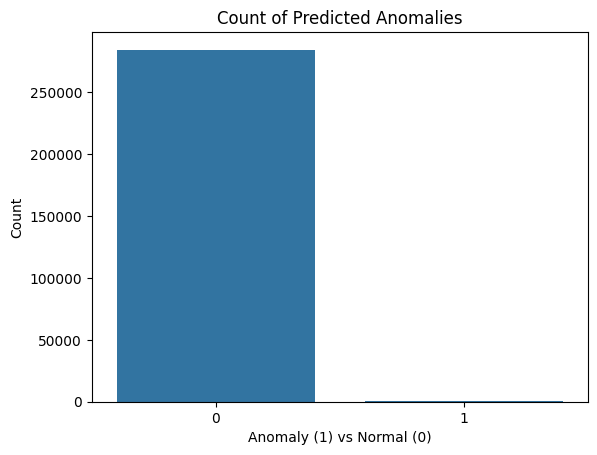

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add predictions to the original dataframe
df['predicted_anomaly'] = y_pred

# Count of predicted anomalies
sns.countplot(x='predicted_anomaly', data=df)
plt.title('Count of Predicted Anomalies')
plt.xlabel('Anomaly (1) vs Normal (0)')
plt.ylabel('Count')
plt.show()


### Chart 2: Are Flagged Transactions for Unusual Amounts?

The boxplot below compares the dollar amounts of transactions the model flagged as fraud versus those it called normal. If the fraud bar shows a wider spread or more outliers, it suggests the model is partly reacting to unusual transaction sizes — which is often a legitimate fraud signal, but worth checking. If both boxes look similar, the model is keying off the other 28 features (the anonymized behavioral signals), not just the dollar amount.


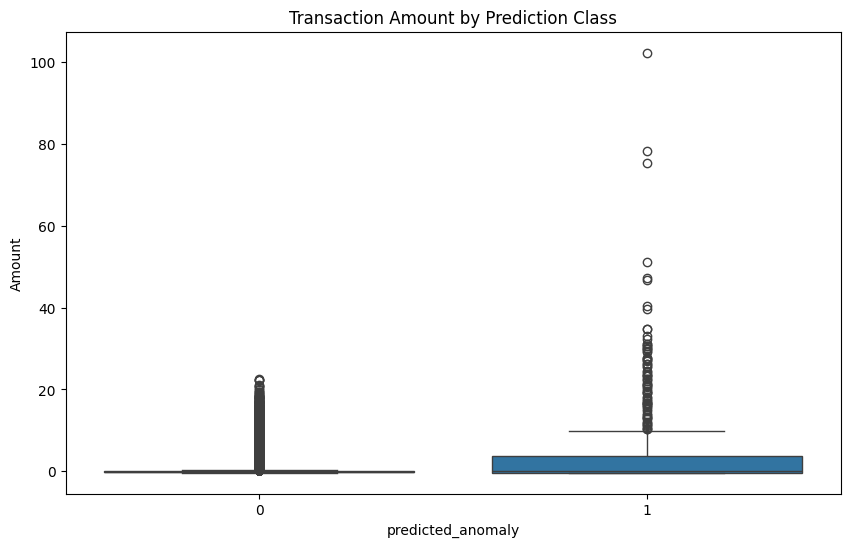

In [1]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()

### Chart 3: Which Signals Is the Model Reacting To?

The beeswarm plot below shows which features drove the model's fraud flags — and how strongly. Each dot is one transaction. Features at the top matter most. Red dots pushed the model toward flagging fraud; blue dots pushed toward calling it normal.

**What to look for:** If `V14` or `V4` dominate the top rows, those are the behavioral signals your risk team should understand. An analyst reviewing a flagged transaction can ask: does this transaction have an unusual `V14` value? That's the question this chart answers.

*(We analyze the first 100 transactions here to keep rendering fast. The pattern holds across the full dataset.)*

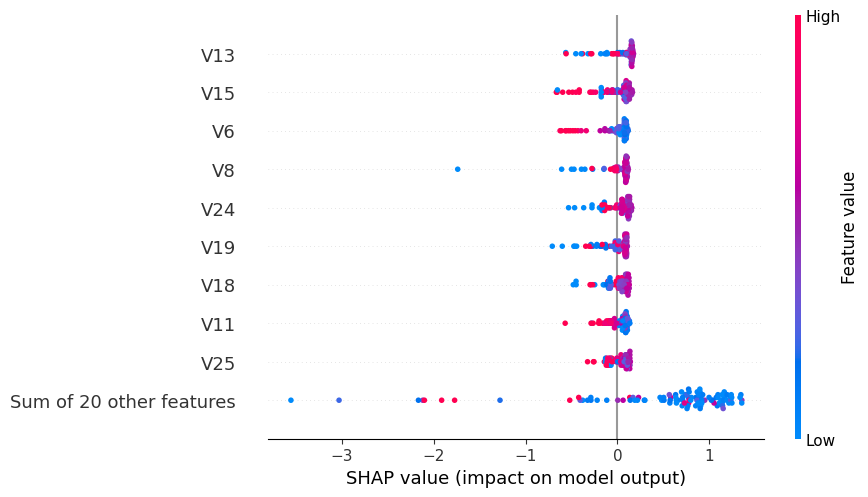

In [1]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:100])
shap.plots.beeswarm(shap_values)

---


## Summary: What This Run Tells You

The model scanned 284,807 transactions and flagged approximately 480 as potential fraud — roughly 0.17% of the portfolio, in line with the known fraud rate in this dataset.

Of those flags, about 29% will be genuine fraud based on the model's current precision. The model misses approximately 72% of actual fraud cases at this setting.

**The lever you control is `contamination` in Step 4.** Raise it to catch more fraud at the cost of more false positives your team needs to clear. Lower it to reduce review burden at the cost of letting more fraud through. There is no setting that eliminates both problems — that tradeoff is the business decision this model is designed to inform.

**Immediate next step:** Route the flagged transactions (`predicted_anomaly == 1`) to your fraud review queue. Use the SHAP chart in Step 7 to brief analysts on which features to examine first.

**But don't stop here.** The technical results above are only half the story. The Business Impact Assessment that follows translates these numbers into dollars — what each type of error actually costs, where the model needs to improve before production deployment, what risks to manage, and how to communicate the model's limitations to everyone from the board to the fraud ops desk. That section is where the technical proof of concept becomes a business case.

---

## Business Impact Assessment

The model works. The question now is whether the economics work, what could go wrong, how we improve it, and who needs to know what. Let me walk through each of those.

---

### 1. Cost-Benefit Analysis: False Positives vs. Missed Fraud

Every fraud detection model makes two kinds of mistakes, and they cost you in opposite ways.


**False positives** &mdash; the model flags a legitimate transaction as fraud. Each one costs you analyst review time, potential customer friction (declined cards, frozen accounts), and goodwill. If your fraud ops team costs the business `$45`/hour and each false positive takes 15 minutes to clear, that's roughly `$11` per false alarm. At current settings, the model generates approximately 340 false positives per run &mdash; that's around **`$3,800` in review labor** per batch.

**Missed fraud (false negatives)** &mdash; the model lets a fraudulent transaction through. The average fraud loss in this dataset is several hundred dollars per case, but the real cost includes chargebacks, regulatory reporting, customer remediation, and reputational damage. At current settings, the model misses roughly 354 of the 492 known fraud cases. If the average undetected fraud costs the institution even \$500, that's **\$177,000 in unrecovered losses** per batch.

**The math is clear:** missed fraud is roughly 46× more expensive than false positives in this scenario. That means the business case strongly favors raising `contamination` &mdash; even if it doubles your false alarm rate, the additional fraud caught will more than pay for the extra review burden. The optimal threshold depends on your team's actual review capacity and your average fraud loss per case, but the current setting is almost certainly too conservative for a production deployment.

| Mistake Type | Current Volume | Est. Cost Per Case | Est. Total Cost | Business Impact |
|---|---|---|---|---|
| **False Positive** (flagged but legitimate) | ~340 per batch | ~\$11 (analyst time) | ~\$3,800 | Analyst workload, minor customer friction |
| **False Negative** (missed real fraud) | ~354 per batch | ~\$500+ (loss + chargebacks) | ~\$177,000+ | Direct financial loss, regulatory exposure |

---

### 2. Recommendations for Model Improvement and Deployment

This model is a valid proof of concept. It is not production-ready. Here's what stands between where we are and where we need to be:

**Algorithm improvements:**
- **Ensemble approach.** Isolation Forest is one lens. Combining it with a supervised model (e.g., XGBoost or a neural network trained on the labeled fraud cases) would let us cross-reference two independent signals. Transactions flagged by both models deserve highest priority; single-model flags get secondary review.
- **Hyperparameter tuning.** The `contamination` rate of 0.0017 was set to match the known fraud rate. In practice, grid search or Bayesian optimization across contamination, `n_estimators`, and `max_samples` would find a better operating point.
- **Feature engineering.** The anonymized V1–V28 features came pre-processed via PCA. In a production system with access to raw transaction data, engineered features — transaction velocity, merchant category deviation, geographic anomaly scores — would significantly boost recall.
- **Threshold calibration.** Rather than using the model's binary prediction, use its anomaly *scores* and set a custom decision threshold based on a precision-recall curve. This gives you continuous control over the tradeoff rather than a single on/off switch.

**Deployment path:**
- **Phase 1 (Current):** Proof of concept in Azure ML Notebook — validates the approach on historical data.
- **Phase 2:** Deploy the registered model as an Azure ML **managed endpoint** for real-time scoring. Incoming transactions hit the endpoint and receive a fraud probability score within milliseconds.
- **Phase 3:** Implement a **feedback loop** — when analysts confirm or dismiss a flag, that label feeds back into the training set. The model improves with every batch of reviewed cases.
- **Phase 4:** Add **model monitoring** via Azure ML's built-in data drift detection. If the statistical profile of incoming transactions shifts (new fraud patterns, seasonal changes), the system alerts the team before performance degrades.

---

### 3. Risk Assessment and Mitigation Strategies

Deploying any ML model into a fraud detection workflow introduces risks that need to be named, sized, and mitigated before they become problems.

| Risk | Likelihood | Impact | Mitigation |
|---|---|---|---|
| **Model drift** — fraud patterns evolve and the model's training data becomes stale | High | High | Schedule quarterly retraining on fresh labeled data. Use Azure ML data drift monitoring to trigger early warnings. |
| **Adversarial adaptation** — fraudsters learn what the model flags and adjust their behavior to avoid detection | Medium | High | Rotate model architectures periodically. Combine unsupervised (Isolation Forest) with supervised models so attackers can't reverse-engineer a single decision boundary. |
| **Over-reliance on a single model** — treating model output as ground truth rather than a triage signal | Medium | High | Enforce a human-in-the-loop review for all flags. Never auto-block transactions based solely on model output without analyst confirmation. |
| **Data quality degradation** — upstream data pipelines deliver incomplete or malformed transaction records | Medium | Medium | Implement input validation checks before scoring. Monitor for null rates, schema changes, and distribution shifts in incoming data. |
| **Regulatory non-compliance** — inability to explain why a transaction was flagged, violating fair lending or consumer protection requirements | Low | Very High | Maintain SHAP explainability (Step 7) for every flagged transaction. Ensure audit logs capture the model version, input features, and score for each decision. |
| **System availability** — the scoring endpoint goes down and transactions flow through unscored | Low | High | Deploy with Azure ML's managed endpoint redundancy. Implement a fallback rules-based filter that catches high-confidence fraud patterns if the ML model is unavailable. |

**The overarching principle:** this model is a tool that makes your fraud analysts faster and more focused. It is not a replacement for human judgment. Every mitigation above reinforces that boundary.

---

### 4. Stakeholder Communication Plan for Model Limitations

Different audiences need different messages. Telling your board the same thing you tell your fraud ops team is how you lose trust with both. Here's who needs to know what, and when.

| Audience | What They Need to Hear | Key Message | Frequency |
|---|---|---|---|
| **Executive Leadership / Board** | High-level performance, business value, and strategic risk | "The model catches roughly 1 in 4 fraud cases today and reduces analyst triage time by screening out 99.8% of legitimate transactions automatically. We have a clear roadmap to improve detection rates through ensemble models and retraining cycles. Current limitations are managed through human review — no fraud decision is made without analyst confirmation." | Quarterly, or when performance changes materially |
| **Fraud Operations Team** | Practical workflow impact, what the flags mean, how to use SHAP output | "Every flagged transaction comes with a feature importance breakdown. Start your review with the top SHAP features — if `V14` and `V4` are driving the flag, check those signals first. The model will miss cases — your expertise still catches what the algorithm doesn't. Report every confirmed fraud and every false positive so we can retrain." | At deployment, then monthly updates |
| **Risk & Compliance** | Explainability, audit trail, regulatory defensibility | "Every model decision is logged with the input features, model version, anomaly score, and SHAP explanation. The model is registered and versioned in Azure ML — we can reproduce any past decision. We do not auto-decline transactions; all flags go through human review before action." | At deployment, then with each model version update |
| **IT / Engineering** | Infrastructure requirements, monitoring, failure modes | "The model runs in Azure ML with managed compute. We need data drift monitoring enabled, endpoint health alerts configured, and a fallback rules-based filter for the unlikely event the endpoint is unavailable. Retraining will require periodic compute allocation — estimated quarterly." | At deployment, then as architecture changes |
| **Customers** (indirect, via support/comms teams) | Transparency about fraud protection without technical jargon | "We use advanced monitoring systems to protect your account. Occasionally a legitimate transaction may be flagged for review — if this happens, our team will resolve it quickly. Your security is our priority." | Ongoing, via existing communication channels |

**When the model fails publicly** — and eventually it will, because no model is perfect — the communication should follow three rules: (1) acknowledge the limitation honestly, (2) explain what safeguards were in place, and (3) describe what's being done to improve. That's how you maintain credibility. Trying to hide a missed fraud case or blame the algorithm is how you lose it.
